# Plot from `evaluate_mmd.py` outputs

Loads `outputs/mmd_summary_dt<0.01>.npz` and re-renders the MMD-vs-time figure and the structural-error bar chart.

Each plot lives in its own cell so you can tweak it independently. All the data needed is in the npz; no model is reloaded here.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

MODEL_NAMES = ["SDE", "Onsager", "HD2"]
MODEL_COLORS = {"HD2": "tab:blue", "Onsager": "tab:orange", "SDE": "tab:green"}
METRIC_KEYS = ["drift", "gradV", "MgradV", "WgradV"]
METRIC_TITLES = {
    "drift":   r"drift rel err",
    "gradV":   r"$\nabla V$ rel err",
    "MgradV":  r"$M\,\nabla V$ rel err",
    "WgradV":  r"$W\,\nabla V$ rel err",
}

def load_npz(path):
    """Load mmd_summary npz; return dict of arrays."""
    return dict(np.load(path, allow_pickle=False))

def per_seed_curves(data, model):
    """Return {seed: mmd_curve} from npz keys like '<model>_seed<seed>'."""
    out = {}
    prefix = f"{model}_seed"
    for k, v in data.items():
        if k.startswith(prefix) and not k.startswith("err_"):
            try:
                out[int(k[len(prefix):])] = v
            except ValueError:
                pass
    return out

In [2]:
# Pick which run to plot.
DT = 0.01      # 0.01 or 0.005
npz_path = f"outputs/mmd_summary_dt{DT}.npz"
data = load_npz(npz_path)

ts = data["ts"]
mmd_ref = data["mmd_ref"]
bandwidth = float(data["bandwidth"])
kappa = float(data["kappa"])
dt = float(data["dt"])

print(f"Loaded {npz_path}")
print(f"  dt={dt}, kappa={kappa}, bandwidth={bandwidth:.4g}, len(ts)={len(ts)}")
for m in MODEL_NAMES:
    seeds = sorted(per_seed_curves(data, m).keys())
    print(f"  {m}: seeds={seeds}")

Loaded outputs/mmd_summary_dt0.01.npz
  dt=0.01, kappa=0.8, bandwidth=0.9776, len(ts)=200
  SDE: seeds=[0, 1, 12, 123, 1234]
  Onsager: seeds=[0, 1, 12, 123, 1234]
  HD2: seeds=[0, 1, 12, 123, 1234]


## MMD² vs time

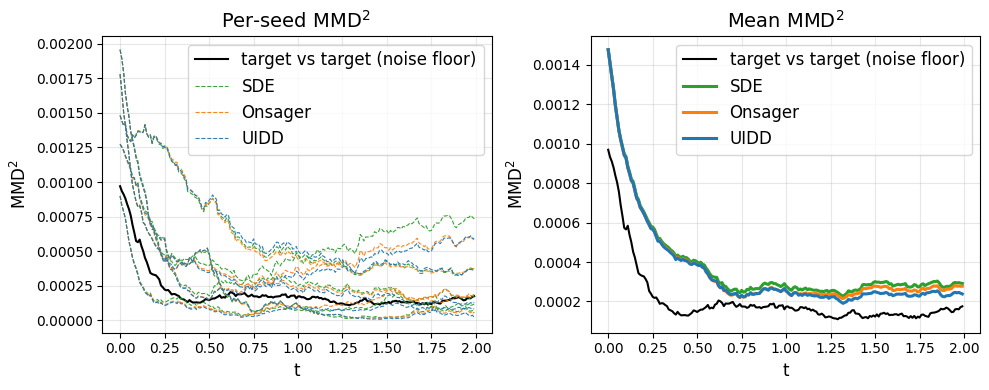

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex=True)
yscale = "linear"
for ax in axes:
    ref = mmd_ref if yscale == "linear" else np.where(mmd_ref > 0, mmd_ref, np.nan)
    ax.plot(ts, ref, color="k", lw=1.5,
            label="target vs target (noise floor)")
for model in MODEL_NAMES:
    ax=axes[0]
    mean_key = f"{model}_mean"
    if mean_key not in data:
        continue
    color = MODEL_COLORS[model]
    mean = data[mean_key]
    std = data[f"{model}_std"]
    n_seeds = int(data[f"{model}_n_seeds"])
    # thin per-seed traces
    for seed, curve in sorted(per_seed_curves(data, model).items()):
        c = curve if yscale == "linear" else np.where(curve > 0, curve, np.nan)

        if seed == seeds[0]:
            model="UIDD" if model == "HD2" else model
            label = f"{model}"
        else:
            label = None
        ax.plot(ts, c, color=color, lw=0.8, ls="--", alpha=0.95, label=label)
    


    # mean curve
    ax=axes[1]
    m_plot = mean if yscale == "linear" else np.where(mean > 0, mean, np.nan)

    model="UIDD" if model == "HD2" else model
    ax.plot(ts, m_plot, color=color, lw=2.2,
            label=f"{model}", ls="-")

for ax in axes:
    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel(r"MMD$^2$", fontsize=12)
    ax.set_yscale(yscale)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best", fontsize=12)

axes[0].set_title(f"Per-seed MMD$^2$ ", fontsize=14)
axes[1].set_title(f"Mean MMD$^2$", fontsize=14)
fig.tight_layout()
fig.savefig(f"mmd_vs_time_dt{dt}.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Structural error bar chart

=== Structural relative errors (dt=0.01, kappa=0.8) ===
metric   model           mean        std  per-seed values
---------------------------------------------------------
drift    SDE        4.508e-02   6.71e-04  s0=4.603e-02  s1=4.490e-02  s12=4.397e-02  s123=4.514e-02  s1234=4.537e-02
drift    Onsager    4.660e-02   3.09e-03  s0=4.776e-02  s1=4.291e-02  s12=4.296e-02  s123=5.021e-02  s1234=4.914e-02
drift    HD2        4.680e-02   2.19e-03  s0=4.865e-02  s1=4.537e-02  s12=5.011e-02  s123=4.440e-02  s1234=4.548e-02

gradV    Onsager    9.917e-01   3.38e-03  s0=9.924e-01  s1=9.856e-01  s12=9.911e-01  s123=9.938e-01  s1234=9.955e-01
gradV    HD2        4.238e-02   2.16e-03  s0=4.286e-02  s1=3.982e-02  s12=4.613e-02  s123=4.229e-02  s1234=4.082e-02

MgradV   Onsager    4.828e-01   3.30e-01  s0=4.265e-01  s1=1.707e-01  s12=2.086e-01  s123=1.089e+00  s1234=5.192e-01
MgradV   HD2        3.941e-02   3.04e-03  s0=4.024e-02  s1=3.715e-02  s12=4.501e-02  s123=3.751e-02  s1234=3.711e-02

WgradV

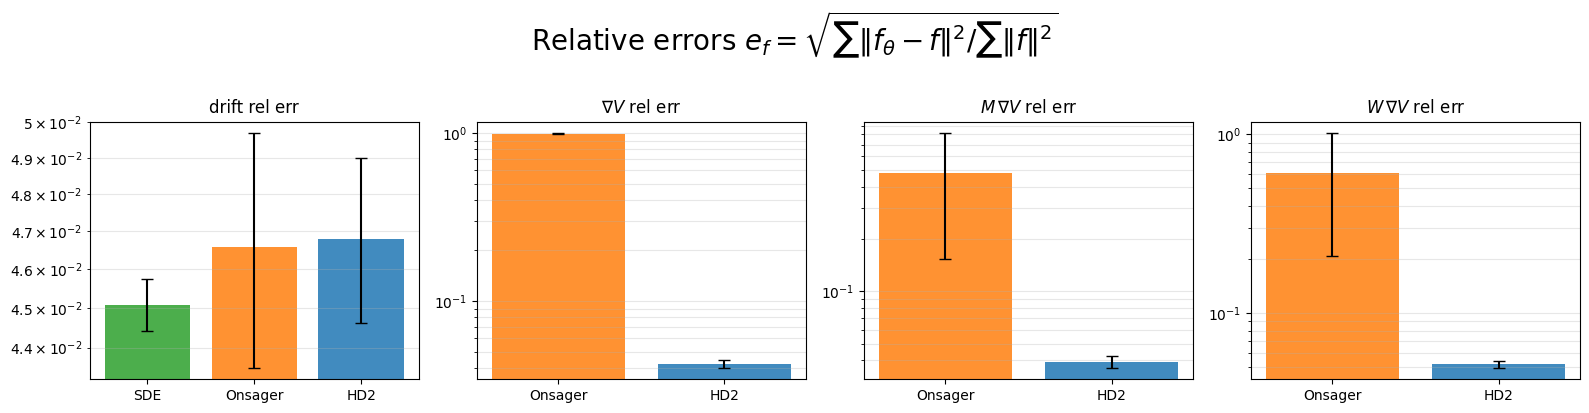

In [6]:
# Print all per-seed and aggregated relative errors before plotting.
print(f"=== Structural relative errors (dt={dt}, kappa={kappa}) ===")
header = f"{'metric':<8} {'model':<8} {'mean':>11}  {'std':>9}  per-seed values"
print(header)
print("-" * len(header))
for k in METRIC_KEYS:
    for m in MODEL_NAMES:
        mean_key = f"err_{m}_{k}_mean"
        if mean_key not in data:
            continue
        mean = float(data[mean_key])
        std = float(data[f"err_{m}_{k}_std"])
        seeds = sorted(per_seed_curves(data, m).keys())
        per_seed_vals = []
        for s in seeds:
            v = data.get(f"err_{m}_seed{s}_{k}")
            if v is not None:
                per_seed_vals.append((s, float(v)))
        seeds_str = "  ".join(f"s{s}={v:.3e}" for s, v in per_seed_vals)
        print(f"{k:<8} {m:<8} {mean:>11.3e}  {std:>9.2e}  {seeds_str}")
    print()

fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes2, METRIC_KEYS):
    means, stds, labels, colors = [], [], [], []
    for m in MODEL_NAMES:
        mean_key = f"err_{m}_{k}_mean"
        if mean_key not in data:
            continue
        means.append(float(data[mean_key]))
        stds.append(float(data[f"err_{m}_{k}_std"]))
        labels.append(m)
        colors.append(MODEL_COLORS[m])
    if not means:
        ax.set_axis_off()
        ax.set_title(METRIC_TITLES[k] + " (no data)")
        continue
    xs = np.arange(len(labels))
    ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85, capsize=4)
    ax.set_xticks(xs)
    ax.set_xticklabels(labels)
    ax.set_yscale("log")
    ax.set_title(METRIC_TITLES[k])
    ax.grid(True, which="both", alpha=0.3, axis="y")
fig2.suptitle(
    rf"Relative errors $e_f=\sqrt{{\sum\|f_\theta-f\|^2/\sum\|f\|^2}}$",
    y=1.02, fontsize=20
)
fig2.tight_layout()
# fig2.savefig(f"metrics_dt{dt}.png", dpi=200, bbox_inches="tight")
plt.show()